# DFT-LRP sanity check (ECG)

This notebook mirrors the upstream `DFT-LRP` tutorial structure, but runs on **your model** and **your data**.

It computes **time-domain LRP relevance** for the positive logit and propagates it to **frequency** and **time–frequency** domains using the official DFT-LRP implementation.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt
import neurokit2 as nk
import pandas as pd

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src" / "ecg_chagas_embeddings").exists():
            return p
    return start

REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
print("cwd:", Path.cwd())

# Local src/ layout
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# Upstream DFT-LRP submodule (expects imports like `import dft_lrp`)
DFT_LRP_CODE_ROOT = REPO_ROOT / "external" / "dft-lrp" / "code"
if str(DFT_LRP_CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(DFT_LRP_CODE_ROOT))

import dft_lrp  # noqa: E402

from ecg_chagas_embeddings.data.datamodule import ECGDataModule # noqa: E402
from ecg_chagas_embeddings.models.resnet18_ecg_flex import LitResNet18 # noqa: E402
import importlib # noqa: E402
import ecg_chagas_embeddings.callbacks.xai_probe as xai_probe # noqa: E402
importlib.reload(xai_probe)
compute_lrp_relevance_time = xai_probe.compute_lrp_relevance_time

torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annota

cwd: /home/flo178/projects/master-thesis/ecg-chagas-embeddings
torch: 2.9.0+cu128
device: cpu


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## 1) Download checkpoint from W&B

Paste the model artifact reference (same structure as the W&B UI snippet):
- `<entity>/<project>/<artifact>:<alias-or-version>`


In [2]:
WANDB_ARTIFACT = "ag-lukassen/ecg-chagas-embeddings-cli/model-sgs3bq5n:v21"
DOWNLOAD_DIR = Path("./artifacts/wandb_downloads").resolve()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

run = wandb.init(job_type="dft_lrp_sanity")
artifact = run.use_artifact(WANDB_ARTIFACT, type="model")
artifact_dir = Path(artifact.download(root=str(DOWNLOAD_DIR)))

ckpts = sorted(artifact_dir.rglob("*.ckpt"))
if not ckpts:
    raise FileNotFoundError(f"No .ckpt found under {artifact_dir}")
ckpt_path = ckpts[0]
print("Downloaded:", ckpt_path)
run.finish()
ckpt_path


wandb: Currently logged in as: floherzler (ag-lukassen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


Downloaded: /home/flo178/projects/master-thesis/ecg-chagas-embeddings/artifacts/wandb_downloads/model.ckpt


PosixPath('/home/flo178/projects/master-thesis/ecg-chagas-embeddings/artifacts/wandb_downloads/model.ckpt')

## 2) Point to your validation data

Defaults are taken from `configs/base.yaml` if env vars are not set:
- `ECG_META_PATH`
- `ECG_DATA_DIR`


In [3]:
def _parse_base_yaml_paths(path: Path) -> tuple[str | None, str | None]:
    text = path.read_text(encoding="utf-8")
    meta_path = None
    data_dir = None
    in_data = False
    for line in text.splitlines():
        if line.strip() == "data:":
            in_data = True
            continue
        if in_data and line and not line.startswith(" "):
            in_data = False
        if not in_data:
            continue
        s = line.strip()
        if s.startswith("meta_path:"):
            meta_path = s.split(":", 1)[1].strip().strip(""").strip("'")
        elif s.startswith("data_dir:"):
            data_dir = s.split(":", 1)[1].strip().strip(""").strip("'")
    return meta_path, data_dir

DEFAULT_META_PATH = None
DEFAULT_DATA_DIR = None
base_yaml = REPO_ROOT / "configs" / "base.yaml"
if base_yaml.exists():
    DEFAULT_META_PATH, DEFAULT_DATA_DIR = _parse_base_yaml_paths(base_yaml)
if not DEFAULT_META_PATH or not DEFAULT_DATA_DIR:
    default_root = REPO_ROOT.parent / "datasets" / "physionet2025" / "processedMaster"
    DEFAULT_META_PATH = str(default_root / "metadata.csv")
    DEFAULT_DATA_DIR = str(default_root / "bp")

META_PATH = os.environ.get("ECG_META_PATH") or DEFAULT_META_PATH
DATA_DIR = os.environ.get("ECG_DATA_DIR") or DEFAULT_DATA_DIR
META_PATH = str(Path(META_PATH).expanduser())
DATA_DIR = str(Path(DATA_DIR).expanduser())

assert Path(META_PATH).exists(), f"metadata.csv not found at {META_PATH} (set ECG_META_PATH to override)"
assert Path(DATA_DIR).exists(), f"tensor folder not found at {DATA_DIR} (set ECG_DATA_DIR to override)"

META_PATH, DATA_DIR


('/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/metadata.csv',
 '/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp')

## 3) Load model + fetch a validation sample

We compute relevance for the **same 2500-sample window** that your model sees.
For visualization, we pick a single lead (default: lead 1 / index 1).


In [4]:
FS_HZ = 400.0
LEAD_INDEX = 7  # choose lead to visualize (0..11)

# Use fold 4 (held-out) so the model has not seen these exams during training.
EVAL_FOLDS = (4,)
# Pick one of: "samitrop_pos", "ptbxl_neg", "code15_pos", "code15_neg".
# TARGET_CASE = "code15_pos"
TARGET_CASE = "samitrop_pos"
AUTO_PICK_EXAMS = True

# Fallback ids (override with your own)
EXAM_IDS = {
    "samitrop_pos": "101282",
    "ptbxl_neg": "17950_hr",
    "code15_pos": "1334451",
    "code15_neg": "755514",
}

def _pick_fold4_exam_ids(meta_path: str, data_dir: str, fold: int = 4) -> dict[str, str]:
    import pandas as pd
    from pathlib import Path

    usecols = [
        "exam_id",
        "patient_id",
        "chagas",
        "fold",
        "source",
        "qc_zhao2018_bp",
        "qc_templatematch_bp",
    ]
    df = pd.read_csv(meta_path, usecols=usecols, low_memory=False)
    df = df[df["fold"] == fold].copy()

    # Normalize dataset source strings ("PTB-XL" -> "PTBXL", etc.)
    src = df["source"].astype(str).str.upper().str.replace(r"[^A-Z0-9]", "", regex=True)
    df["_src_norm"] = src

    data_dir_p = Path(data_dir)

    def _exists_here(exam_id: str) -> bool:
        return (data_dir_p / f"{exam_id}.pt").is_file()

    # Prefer high templatematch if available, but don't enforce any QC filters.
    df["_qc_tm"] = pd.to_numeric(df["qc_templatematch_bp"], errors="coerce")
    df = df.sort_values("_qc_tm", ascending=False, na_position="last")

    want = [
        ("samitrop_pos", "SAMITROP", 1),
        ("ptbxl_neg", "PTBXL", 0),
        ("code15_pos", "CODE15", 1),
        ("code15_neg", "CODE15", 0),
    ]

    out: dict[str, str] = {}
    used_patients: set[str] = set()
    for key, src_norm, label in want:
        sub = df[(df["_src_norm"] == src_norm) & (df["chagas"] == label)]
        for _, row in sub.head(20000).iterrows():
            eid = str(row["exam_id"])
            pid = str(row.get("patient_id", ""))
            if pid and pid in used_patients:
                continue
            if not _exists_here(eid):
                continue
            out[key] = eid
            if pid:
                used_patients.add(pid)
            break

    return out

if AUTO_PICK_EXAMS:
    try:
        picked = _pick_fold4_exam_ids(META_PATH, DATA_DIR, fold=EVAL_FOLDS[0])
        for k, v in picked.items():
            if v and not EXAM_IDS.get(k):
                EXAM_IDS[k] = v
    except Exception as e:
        print("[WARN] Auto-pick from metadata failed; using fallback EXAM_IDS. Error:", e)

TARGET_EXAM_ID = EXAM_IDS[TARGET_CASE]
assert TARGET_EXAM_ID, f"EXAM_IDS[{TARGET_CASE!r}] is empty; fill it manually or enable AUTO_PICK_EXAMS"
print("Using fold-4 exam ids:", EXAM_IDS, "| TARGET_CASE=", TARGET_CASE, "| TARGET_EXAM_ID=", TARGET_EXAM_ID)

model = LitResNet18.load_from_checkpoint(str(ckpt_path), log_umap=False, strict=False)
model.to(device).eval()

dm = ECGDataModule(
    meta_path=META_PATH,
    data_dir=DATA_DIR,
    batch_size=64,
    num_workers=0,
    prefetch_factor=2,
    train_folds=(0, 1, 2, 3),
    valid_folds=EVAL_FOLDS,
    oversample=False,
    pos_fraction=0.05,
)
dm.setup("fit")
val_loader = dm.val_dataloader()

# Fetch the exact exam by id from the fold-4 dataset (ensures we're not accidentally visualizing fold-3).
val_ds = val_loader.dataset
matches = np.where(val_ds.metadata["exam_id"].astype(str).values == str(TARGET_EXAM_ID))[0]
assert len(matches) > 0, f"exam_id={TARGET_EXAM_ID} not found in fold {EVAL_FOLDS}"
sample = val_ds[int(matches[0])]

x = sample.get("ecg")
if x is None and "ecg_views" in sample:
    x = sample["ecg_views"][0]
y = sample["chagas"].view(-1)
exam_id = sample.get("exam_id")

x = x.unsqueeze(0).to(device=device, dtype=torch.float32)  # [1,12,2500]
y = y.to(device=device)
sample_idx = 0

with torch.no_grad():
    logits = model(x)
    if isinstance(logits, (tuple, list)):
        logits = logits[-1]
    if logits.ndim == 2 and logits.shape[1] == 1:
        logits = logits[:, 0]
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).to(torch.int64)

y_int = (y > 0.5).to(torch.int64)
meta_row = val_ds.metadata.iloc[int(matches[0])].to_dict()
case_info = {
    "exam_id": str(meta_row.get("exam_id", TARGET_EXAM_ID)),
    "patient_id": str(meta_row.get("patient_id", "")),
    "source": str(meta_row.get("source", "")),
    "chagas": int(meta_row.get("chagas", int((y_int[sample_idx] > 0).item()))),
    "qc_zhao2018_bp": str(meta_row.get("qc_zhao2018_bp", "")),
    "qc_templatematch_bp": meta_row.get("qc_templatematch_bp", None),
}

print("label=", int(y_int[sample_idx].item()), "pred=", int(preds[sample_idx].item()))
print("exam_id=", exam_id, "| source=", case_info["source"], "| patient_id=", case_info["patient_id"])
prob_sample = float(probs[sample_idx].item())
logit_sample = float(logits[sample_idx].item())
print("p(chagas)=", prob_sample, "logit=", logit_sample)
print("qc_zhao2018_bp=", case_info["qc_zhao2018_bp"], "qc_templatematch_bp=", case_info["qc_templatematch_bp"])


Using fold-4 exam ids: {'samitrop_pos': '101282', 'ptbxl_neg': '17950_hr', 'code15_pos': '1334451', 'code15_neg': '755514'} | TARGET_CASE= samitrop_pos | TARGET_EXAM_ID= 101282


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['criterion.bce_fn.pos_weight']


Train Transform kwargs: {'crop_size': 2500, 'n_views': 2, 'max_mask_duration': 50, 'time_mask_apply_prob': 1.0, 'mask_prob': 0.5, 'channel_mask_apply_prob': 1.0, 'gaussian_noise_std': 0.01, 'per_view_noise': True, 'scaling': (0.8, 1.2), 'per_view_scaling': True, 'max_time_warp': 0.2, 'per_view_warp': False, 'wandering_max_amplitude': 1.0, 'wandering_frequency_range': (0.5, 2.0), 'per_view_wandering': False}
train num_workers 8 pin_memory False
train worker_init_fn None
val num_workers 8 pin_memory False
val worker_init_fn None
label= 1 pred= 0
exam_id= 101282 | source= SaMi-Trop | patient_id= 101282
p(chagas)= 0.34058427810668945 logit= -0.660691499710083
qc_zhao2018_bp= Excellent qc_templatematch_bp= 0.9662575896757774


## ECG delineation (NeuroKit2) for the selected sample

This uses the *same preprocessed tensor* you feed into the model (``x``) and delineates a single lead via NeuroKit2.
We print the returned delineation table so you can later aggregate DFT-LRP relevance per beat segment (P / QRS / T).


,exam_id,source,patient_id,chagas,qc_zhao2018_bp,qc_templatematch_bp,lead_index,n_rpeaks,T
0,101282,SaMi-Trop,101282,1,Excellent,0.966258,7,6,2500


,ECG_P_Offsets,ECG_P_Onsets,ECG_P_Peaks,ECG_Q_Peaks,ECG_R_Offsets,ECG_R_Onsets,ECG_S_Peaks,ECG_T_Offsets,ECG_T_Onsets,ECG_T_Peaks
0,311,293,301,345,378,338,369,514,441,474
1,671,652,661,742,775,733,766,908,837,873
2,1086,1064,1082,1139,1173,1123,1164,1304,1238,1272
3,1467,1440,1454,1506,1569,1494,1560,1702,1633,1668
4,1902,1858,1882,1921,1965,1913,1955,2097,2036,2062
5,2248,2222,2230,2320,2354,2314,2345,2484,2414,2454


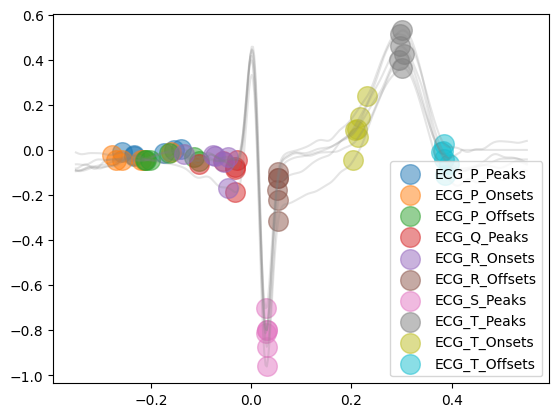

In [5]:
from IPython.display import display

# Use the already-loaded model input window (x: [1,12,T])
SAMPLING_RATE = int(FS_HZ)
lead = int(LEAD_INDEX)
ecg_signal = x[0, lead].detach().cpu().numpy().astype("float64", copy=False)

# Clean -> R-peaks -> delineation
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=SAMPLING_RATE, method="neurokit")
signals_peaks, info_peaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=SAMPLING_RATE)
rpeaks = info_peaks["ECG_R_Peaks"]

signal_dwt, waves_dwt = nk.ecg_delineate(
    ecg_cleaned,
    rpeaks,
    sampling_rate=SAMPLING_RATE,
    method="dwt",
    show=True,
    show_type='all',
)

# Returned wave indices as a rectangular table (columns can have different lengths).
waves_df = pd.DataFrame({k: pd.Series(v) for k, v in waves_dwt.items()}).sort_index(axis=1)

display(pd.DataFrame([{
    "exam_id": case_info.get("exam_id", str(TARGET_EXAM_ID)),
    "source": case_info.get("source", ""),
    "patient_id": case_info.get("patient_id", ""),
    "chagas": case_info.get("chagas", None),
    "qc_zhao2018_bp": case_info.get("qc_zhao2018_bp", None),
    "qc_templatematch_bp": case_info.get("qc_templatematch_bp", None),
    "lead_index": lead,
    "n_rpeaks": int(len(rpeaks)),
    "T": int(ecg_signal.shape[0]),
}]))

display(waves_df.head(6))


## 4) DFT-LRP (time → frequency / time–frequency) + plotting (3×2 grid)

This is the same structure as the upstream tutorial: time signal + relevance, time–frequency signal + relevance, frequency magnitude + relevance.


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/external/dft-lrp/code/dft_lrp.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input, dtype=dtype)


STDFT window_width= 20 n_windows= 125
signal_timefreq.shape= (1, 125, 1251)
relevance_timefreq.shape= (1, 125, 1251)


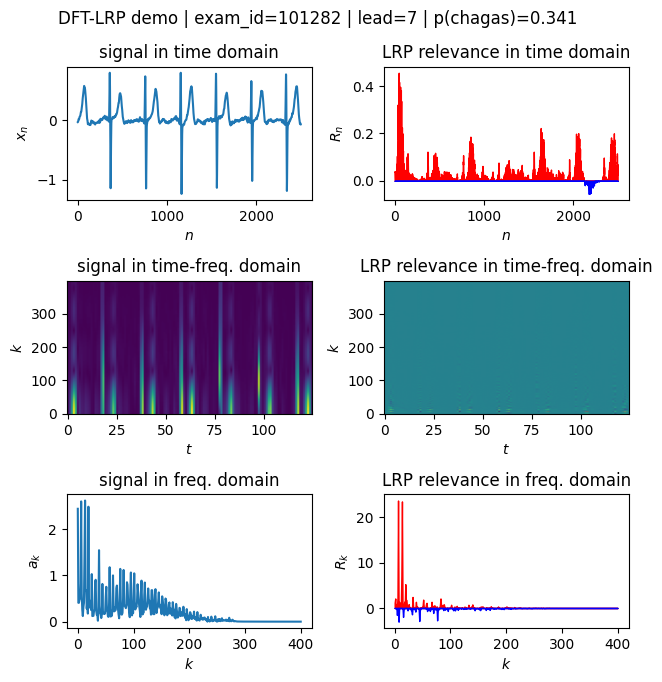

In [6]:
def replace_positive(x: np.ndarray, positive: bool = True) -> np.ndarray:
    mask = x > 0 if positive else x < 0
    x_mod = x.copy()
    x_mod[mask] = 0
    return x_mod

# Compute time-domain LRP relevance for the full multi-lead input
with torch.inference_mode(False), torch.enable_grad(), torch.autocast(device_type=device.type, enabled=False):
    relevance_time = compute_lrp_relevance_time(pl_module=model, x=x)  # [B,12,2500]

T = x.shape[-1]
signal_time = x[:, LEAD_INDEX, :].detach().cpu().numpy()
relevance_time_1d = relevance_time[:, LEAD_INDEX, :].detach().cpu().numpy()

# --- DFT-LRP to frequency domain ---
dftlrp = dft_lrp.DFTLRP(
    T,
    leverage_symmetry=True,
    precision=32,
    cuda=(device.type == "cuda"),
    create_stdft=False,
    create_inverse=False,
)

signal_freq, relevance_freq = dftlrp.dft_lrp(
    relevance_time_1d[[sample_idx]],
    signal_time[[sample_idx]],
    real=False,
    short_time=False,
    epsilon=1e-6,
)

# --- DFT-LRP to time–frequency domain (STDFT) ---
# Note: upstream STDFT uses DFT length = T. Its inverse normalizes by window coverage;
# if `window_width` does not divide `T`, the tail is uncovered -> divide-by-zero -> NaNs.
def _choose_window_width(signal_length: int, preferred: int = 128, min_w: int = 32, max_w: int = 512) -> int:
    upper = min(max_w, signal_length)
    candidates = [w for w in range(min_w, upper + 1) if signal_length % w == 0]
    if not candidates:
        return signal_length
    return min(candidates, key=lambda w: abs(w - preferred))

# WINDOW_WIDTH = _choose_window_width(T, preferred=25)
WINDOW_WIDTH = 20 # T is 2500 samples -> 125 windows
# Note: in the upstream submodule, `window_shift` is a *shift factor*; the effective hop is D = window_width // window_shift.
# Therefore, `WINDOW_SHIFT = 1` implies D = H (no overlap), matching the paper's time-bin conservation condition.
WINDOW_SHIFT = 1
print("STDFT window_width=", WINDOW_WIDTH, "n_windows=", T // WINDOW_WIDTH)
dftlrp_tf = dft_lrp.DFTLRP(
    T,
    leverage_symmetry=True,
    precision=32,
    cuda=(device.type == "cuda"),
    window_shift=WINDOW_SHIFT,
    window_width=WINDOW_WIDTH,
    window_shape="rectangle",
    create_dft=False,
    create_inverse=False,
)
signal_timefreq, relevance_timefreq = dftlrp_tf.dft_lrp(
    relevance_time_1d[[sample_idx]],
    signal_time[[sample_idx]],
    real=False,
    short_time=True,
    epsilon=1e-6,
)

signal_timefreq = np.nan_to_num(signal_timefreq, nan=0.0, posinf=0.0, neginf=0.0)
relevance_timefreq = np.nan_to_num(relevance_timefreq, nan=0.0, posinf=0.0, neginf=0.0)
print("signal_timefreq.shape=", signal_timefreq.shape)
print("relevance_timefreq.shape=", relevance_timefreq.shape)

# Plot (adapted from upstream tutorial)
k_max = min(400, relevance_freq.shape[-1])  # use <=~64 Hz for fs=400, T=2500 => ~0.16 Hz/bin
nrows, ncols = 3, 2
figsize = (2 * 3.29, 2 * 3.29 / ncols * nrows * 1.4 / 2)
fig, ax = plt.subplots(nrows, ncols, figsize=figsize)

x_n = np.linspace(0, T, T)
ax[0, 0].plot(x_n, signal_time[sample_idx])
ax[0, 1].fill_between(x_n, replace_positive(relevance_time_1d[sample_idx], positive=False), color="red")
ax[0, 1].fill_between(x_n, replace_positive(relevance_time_1d[sample_idx]), color="blue")
ax[0, 0].set_xlabel("$n$")
ax[0, 1].set_xlabel("$n$")
ax[0, 0].set_ylabel("$x_n$")
ax[0, 1].set_ylabel("$R_n$")
ax[0, 0].set_title("signal in time domain")
ax[0, 1].set_title("LRP relevance in time domain")

ax[1, 0].imshow(np.abs(signal_timefreq[0, :, :k_max].T), aspect="auto", origin="lower")
ax[1, 1].imshow(relevance_timefreq[0, :, :k_max].T, aspect="auto", origin="lower")
ax[1, 0].set_xlabel("$t$")
ax[1, 1].set_xlabel("$t$")
ax[1, 0].set_ylabel("$k$")
ax[1, 1].set_ylabel("$k$")
ax[1, 0].set_title("signal in time-freq. domain")
ax[1, 1].set_title("LRP relevance in time-freq. domain")

x_k = np.linspace(0, k_max, k_max)
ax[2, 0].plot(x_k, np.abs(signal_freq[0, :k_max]))
ax[2, 1].fill_between(x_k, replace_positive(relevance_freq[0, :k_max], positive=False), color="red")
ax[2, 1].fill_between(x_k, replace_positive(relevance_freq[0, :k_max]), color="blue")
ax[2, 0].set_xlabel("$k$")
ax[2, 1].set_xlabel("$k$")
ax[2, 0].set_ylabel("$a_k$")
ax[2, 1].set_ylabel("$R_k$")
ax[2, 0].set_title("signal in freq. domain")
ax[2, 1].set_title("LRP relevance in freq. domain")

fig.suptitle(f"DFT-LRP demo | exam_id={exam_id[sample_idx] if isinstance(exam_id, (list, tuple)) else exam_id} | lead={LEAD_INDEX} | p(chagas)={prob_sample:.3f}")
plt.tight_layout()
plt.show()


## Beat-level aggregation (P/QRS/T × bands)

This implements the beat-normalized aggregation described in `scripts/analysis/XAI_BEAT_AGGREGATION.md` for **this single sample**.
It maps NeuroKit2 delineation intervals to STDFT windows (overlap-weighted), sums absolute STDFT relevance in fixed bands, then normalizes per beat and averages across beats.


n_beats_used = 6


,P,QRS,T,Between
vhigh,0.001736,-0.000974,0.000663,0.002333
high,0.004147,0.033931,-0.005043,0.001576
mid,-0.001235,0.036161,0.040170,0.017197
low,0.019564,0.057702,0.550642,0.095085


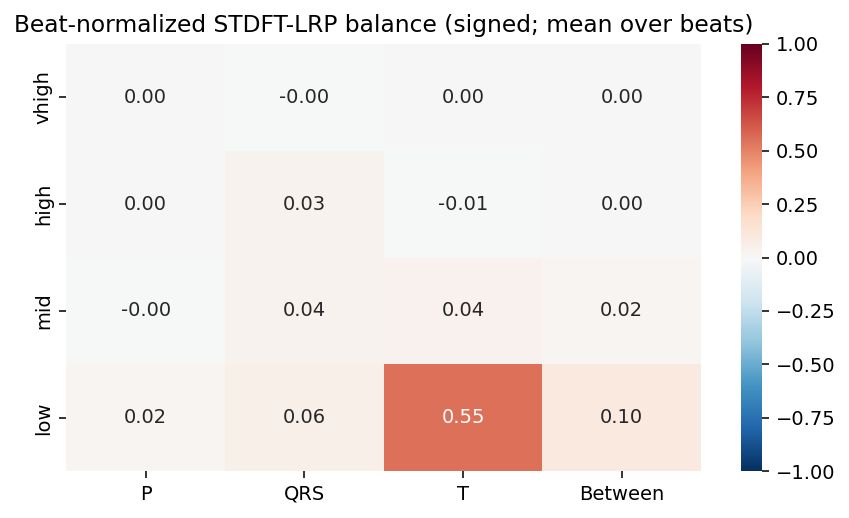

In [7]:
import seaborn as sns

# --- configuration (keep fixed across samples) ---
FREQ_BANDS = {
    'low': (0.67, 4.0),
    'mid': (4.0, 12.0),
    'high': (12.0, 25.0),
    'vhigh': (25.0, 45.0),
}

# We use the same STDFT settings as above: window width H and D=H (non-overlapping).
H = int(WINDOW_WIDTH)
assert int(WINDOW_SHIFT) == 1, 'Use WINDOW_SHIFT=1 so hop D = H (paper condition D=H)'
R = np.asarray(relevance_timefreq)[0].astype(np.float32)  # [n_windows, F], signed
n_windows, F = R.shape

# Frequency grid for STDFT bins (RFFT-like)
freqs = np.fft.rfftfreq(T, d=1.0 / FS_HZ).astype(np.float32)
assert freqs.shape[0] == F, (freqs.shape, F)

band_names = list(FREQ_BANDS.keys())
band_masks = []
for name in band_names:
    lo, hi = FREQ_BANDS[name]
    band_masks.append((freqs >= float(lo)) & (freqs < float(hi)))
band_masks = np.stack(band_masks, axis=0)  # [n_bands, F]

# Precompute per-window *signed* band mass: band_mass[m, b] = sum_{k in band} R[m,k]
band_mass = np.zeros((n_windows, len(band_names)), dtype=np.float32)
for bi in range(len(band_names)):
    band_mass[:, bi] = R[:, band_masks[bi]].sum(axis=1)

def _mid(a: int, b: int) -> int:
    return int((int(a) + int(b)) // 2)

def _overlap_weights(t_on: int, t_off: int) -> tuple[np.ndarray, np.ndarray]:
    # Segment indices are inclusive; convert to half-open [start, end)
    seg_start = max(0, int(t_on))
    seg_end = int(t_off) + 1
    if seg_end <= seg_start:
        return np.zeros((0,), dtype=np.int64), np.zeros((0,), dtype=np.float32)
    m0 = seg_start // H
    m1 = (seg_end - 1) // H
    m0 = max(0, int(m0))
    m1 = min(int(m1), n_windows - 1)
    if m1 < m0:
        return np.zeros((0,), dtype=np.int64), np.zeros((0,), dtype=np.float32)
    ms = np.arange(m0, m1 + 1, dtype=np.int64)
    w_start = ms * H
    w_end = (ms + 1) * H
    overlap = np.maximum(0, np.minimum(w_end, seg_end) - np.maximum(w_start, seg_start)).astype(np.float32)
    ws = overlap / float(H)
    keep = ws > 0
    return ms[keep], ws[keep]

# New segmentation rules with midpoint disambiguation and a 4th 'between beats' segment.
# For beat b, define:
#   P      : P_on -> mid(P_off, R_on)
#   QRS    : mid(P_off, R_on) -> mid(R_off, T_on)
#   T      : mid(R_off, T_on) -> T_off
#   Between: T_off -> next P_on (if exists)
seg_names = ['P', 'QRS', 'T', 'Between']

required_cols = [
    'ECG_P_Onsets', 'ECG_P_Offsets',
    'ECG_R_Onsets', 'ECG_R_Offsets',
    'ECG_T_Onsets', 'ECG_T_Offsets',
]
missing_cols = [c for c in required_cols if c not in waves_df.columns]
if missing_cols:
    raise RuntimeError(f'Missing delineation columns: {missing_cols}')

beat_mats = []
n_beats_guess = int(max(len(waves_df[col]) for col in required_cols))
for b in range(n_beats_guess):
    # Skip beats with missing indices
    vals = {c: waves_df.iloc[b][c] for c in required_cols}
    if any(pd.isna(v) for v in vals.values()):
        continue
    p_on = int(vals['ECG_P_Onsets'])
    p_off = int(vals['ECG_P_Offsets'])
    r_on = int(vals['ECG_R_Onsets'])
    r_off = int(vals['ECG_R_Offsets'])
    t_on = int(vals['ECG_T_Onsets'])
    t_off = int(vals['ECG_T_Offsets'])

    m1 = _mid(p_off, r_on)
    m2 = _mid(r_off, t_on)

    segs = [
        ('P', p_on, m1),
        ('QRS', m1, m2),
        ('T', m2, t_off),
    ]

    # Between-beats segment only if next P_on exists
    if b + 1 < n_beats_guess:
        next_p_on = waves_df.iloc[b + 1]['ECG_P_Onsets']
        if not pd.isna(next_p_on):
            segs.append(('Between', t_off, int(next_p_on)))

    mat = np.zeros((len(seg_names), len(band_names)), dtype=np.float32)
    any_seg = False
    for si, (sname, t_on, t_off) in enumerate(segs):
        ms, ws = _overlap_weights(int(t_on), int(t_off))
        if ms.size == 0:
            continue
        any_seg = True
        mat[si, :] = (band_mass[ms, :] * ws[:, None]).sum(axis=0)

    if not any_seg:
        continue

    # Signed normalization: divide by total absolute mass so values stay in [-1, 1].
    denom = float(np.abs(mat).sum())
    if denom <= 0:
        continue
    beat_mats.append(mat / denom)

if not beat_mats:
    raise RuntimeError('No beats with valid delineation segments found for this sample')
beat_mats = np.stack(beat_mats, axis=0)  # [n_beats, 4, n_bands]
sample_mat = beat_mats.mean(axis=0).T    # [n_bands, 4]

# Reverse the row order so 'low' is at the bottom and 'high' is at the top
df_plot = pd.DataFrame(sample_mat, index=band_names, columns=seg_names).iloc[::-1]

print('n_beats_used =', beat_mats.shape[0])
display(df_plot)

plt.figure(figsize=(6.2, 3.8), dpi=140)
sns.heatmap(
    df_plot,
    annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1.0, vmax=1.0
)
plt.title('Beat-normalized STDFT-LRP balance (signed; mean over beats)')
plt.tight_layout()
plt.show()


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/external/dft-lrp/code/dft_lrp.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input, dtype=dtype)
/home/flo178/projects/master-thesis/ecg-chagas-embeddings/external/dft-lrp/code/dft_lrp.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input, dtype=dtype)
/home/flo178/projects/master-thesis/ecg-chagas-embeddings/external/dft-lrp/code/dft_lrp.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input, dtype=dtype

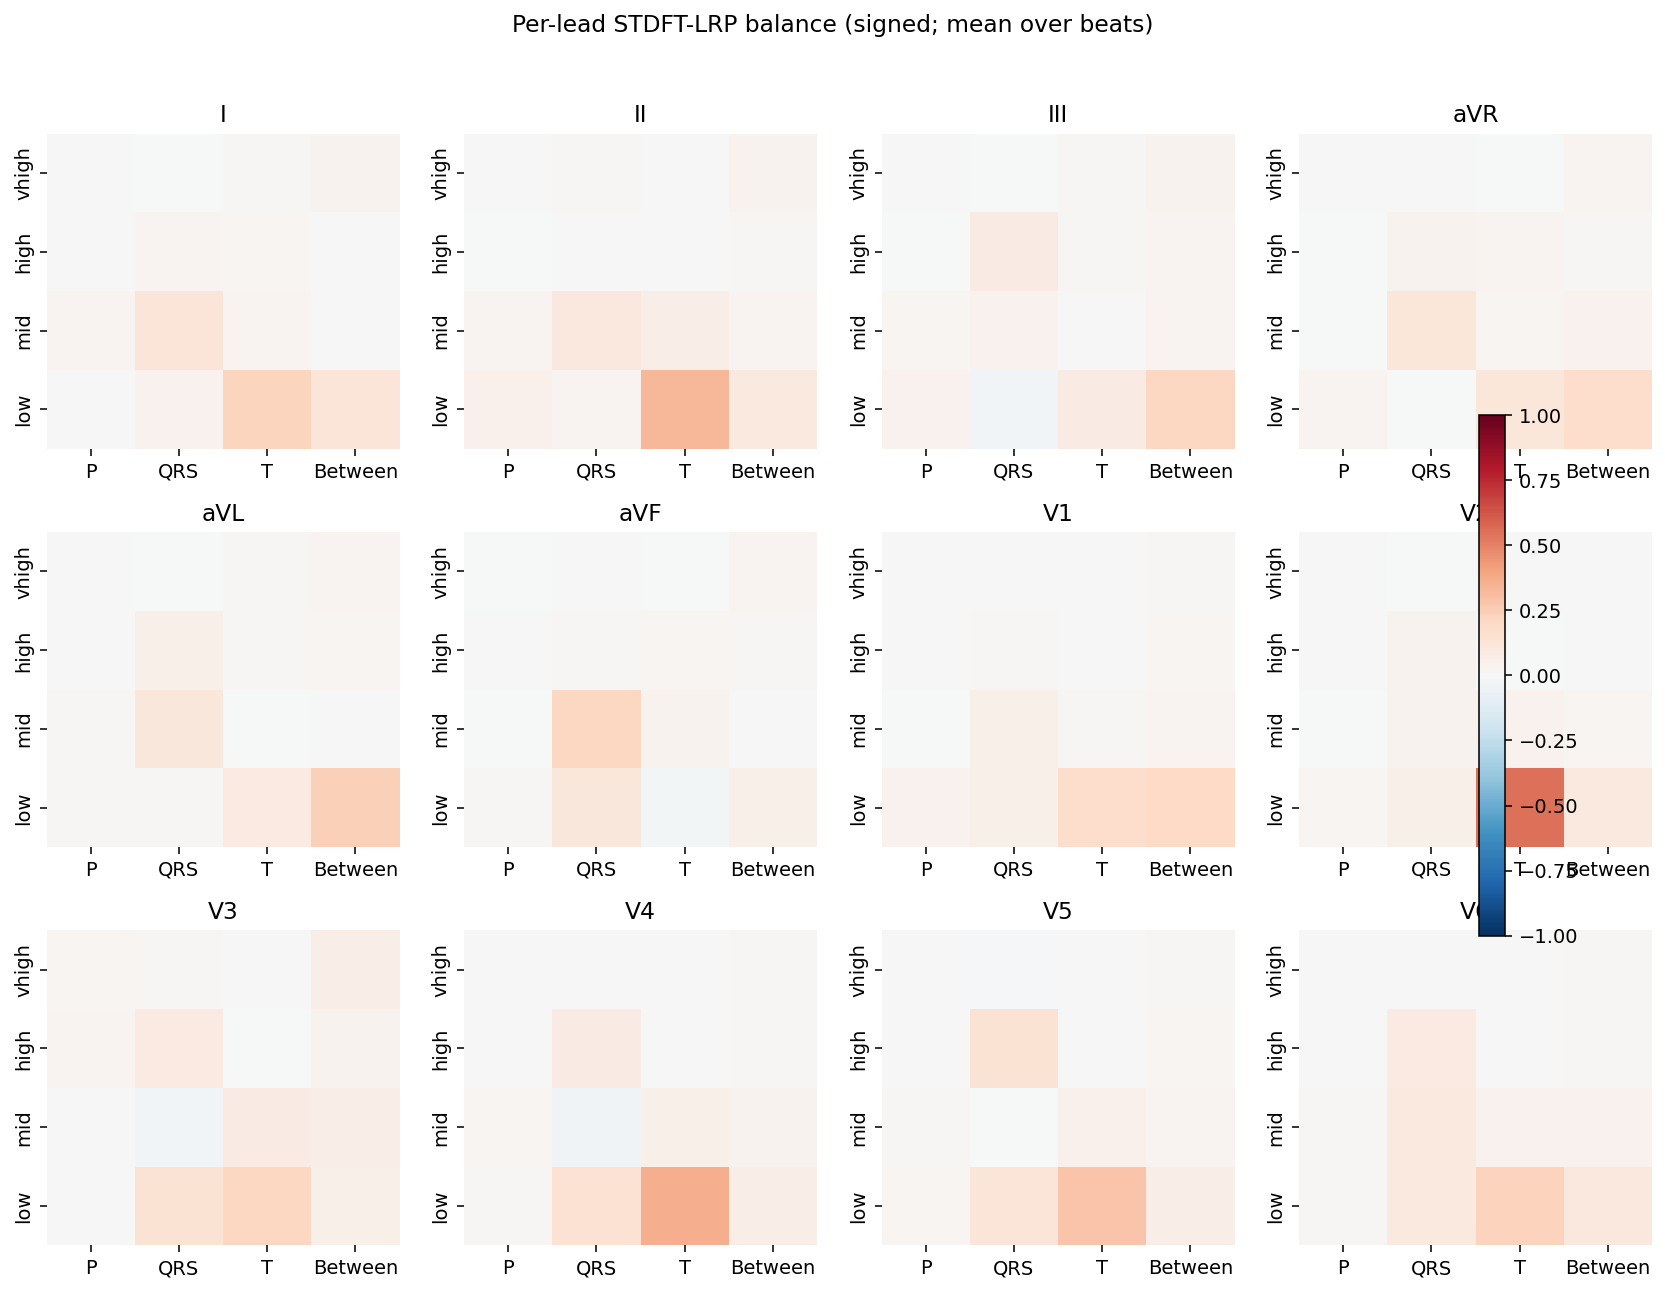

In [8]:
import matplotlib as mpl
# --- Per-lead 4×4 heatmaps (signed balance) ---

lead_indices = list(range(x.shape[1]))  # all leads
lead_names = [
    "I",
    "II",
    "III",
    "aVR",
    "aVL",
    "aVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
]


def _compute_lead_matrix(
    rel_tf: np.ndarray, waves_df: pd.DataFrame
) -> pd.DataFrame | None:
    n_windows, F = rel_tf.shape
    band_mass = np.zeros((n_windows, len(band_names)), dtype=np.float32)
    for bi, mask in enumerate(band_masks):
        band_mass[:, bi] = rel_tf[:, mask].sum(axis=1)

    beat_mats = []
    n_beats_guess = len(waves_df)
    for b in range(n_beats_guess):
        vals = waves_df.iloc[b]
        needed = [
            "ECG_P_Onsets",
            "ECG_P_Offsets",
            "ECG_R_Onsets",
            "ECG_R_Offsets",
            "ECG_T_Onsets",
            "ECG_T_Offsets",
        ]
        if any(pd.isna(vals[k]) for k in needed):
            continue

        p_on = int(vals["ECG_P_Onsets"])
        p_off = int(vals["ECG_P_Offsets"])
        r_on = int(vals["ECG_R_Onsets"])
        r_off = int(vals["ECG_R_Offsets"])
        t_on = int(vals["ECG_T_Onsets"])
        t_off = int(vals["ECG_T_Offsets"])

        m1 = _mid(p_off, r_on)
        m2 = _mid(r_off, t_on)

        segs = [
            ("P", p_on, m1),
            ("QRS", m1, m2),
            ("T", m2, t_off),
        ]

        if b + 1 < n_beats_guess:
            next_p_on = waves_df.iloc[b + 1]["ECG_P_Onsets"]
            if not pd.isna(next_p_on):
                segs.append(("Between", t_off, int(next_p_on)))

        mat = np.zeros((len(seg_names), len(band_names)), dtype=np.float32)
        any_seg = False
        for si, (_sname, t_on, t_off) in enumerate(segs):
            ms, ws = _overlap_weights(int(t_on), int(t_off))
            if ms.size == 0:
                continue
            any_seg = True
            mat[si, :] = (band_mass[ms, :] * ws[:, None]).sum(axis=0)

        if not any_seg:
            continue
        denom = float(np.abs(mat).sum())
        if denom <= 0:
            continue
        beat_mats.append(mat / denom)

    if not beat_mats:
        return None

    beat_mats = np.stack(beat_mats, axis=0)
    sample_mat = beat_mats.mean(axis=0).T  # [bands, segs]
    return pd.DataFrame(sample_mat, index=band_names, columns=seg_names).iloc[::-1]


per_lead_dfs = []
for lead in lead_indices:
    sig_1d = x[0, lead, :].detach().cpu().numpy().astype(np.float64, copy=False)
    rel_1d = (
        relevance_time[0, lead, :].detach().cpu().numpy().astype(np.float32, copy=False)
    )

    try:
        ecg_cleaned = nk.ecg_clean(sig_1d, sampling_rate=int(FS_HZ), method="neurokit")
        _signals_peaks, info_peaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=int(FS_HZ))
        rpeaks = info_peaks["ECG_R_Peaks"]
        _sig_dwt, waves_dwt = nk.ecg_delineate(
            ecg_cleaned,
            rpeaks,
            sampling_rate=int(FS_HZ),
            method="dwt",
            show=False,
        )
        waves_df = pd.DataFrame({k: pd.Series(v) for k, v in waves_dwt.items()})
    except Exception:
        per_lead_dfs.append(None)
        continue

    try:
        _sig_tf, rel_tf = dftlrp_tf.dft_lrp(
            rel_1d[None, :],
            sig_1d[None, :],
            real=False,
            short_time=True,
            epsilon=1e-6,
        )
        rel_tf = np.asarray(rel_tf)[0].astype(np.float32)
    except Exception:
        per_lead_dfs.append(None)
        continue

    per_lead_dfs.append(_compute_lead_matrix(rel_tf, waves_df))

ncols = 4
nrows = int(np.ceil(len(lead_indices) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 3.0), dpi=140)
axes = np.atleast_1d(axes).ravel()

for i, lead in enumerate(lead_indices):
    ax = axes[i]
    df_plot = per_lead_dfs[i]
    if df_plot is None:
        ax.axis("off")
        ax.set_title(f"Lead {lead + 1} (no beats)")
        continue
    sns.heatmap(
        df_plot,
        ax=ax,
        annot=False,
        cmap="RdBu_r",
        vmin=-1.0,
        vmax=1.0,
        cbar=False,
    )
    title = lead_names[lead] if lead < len(lead_names) else f"Lead {lead + 1}"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(len(lead_indices), len(axes)):
    axes[j].axis("off")

# Shared colorbar
sm = mpl.cm.ScalarMappable(
    cmap="RdBu_r", norm=mpl.colors.Normalize(vmin=-1.0, vmax=1.0)
)
sm.set_array([])
fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.02)

plt.suptitle("Per-lead STDFT-LRP balance (signed; mean over beats)", y=1.02)
plt.tight_layout()
plt.show()



## 5) Paper-style composite plot (Fig. 7-like)

This composes the DFT-LRP outputs into a compact layout: center time–frequency map, bottom time trace with signed relevance overlay, and left spectrum with signed relevance overlay.


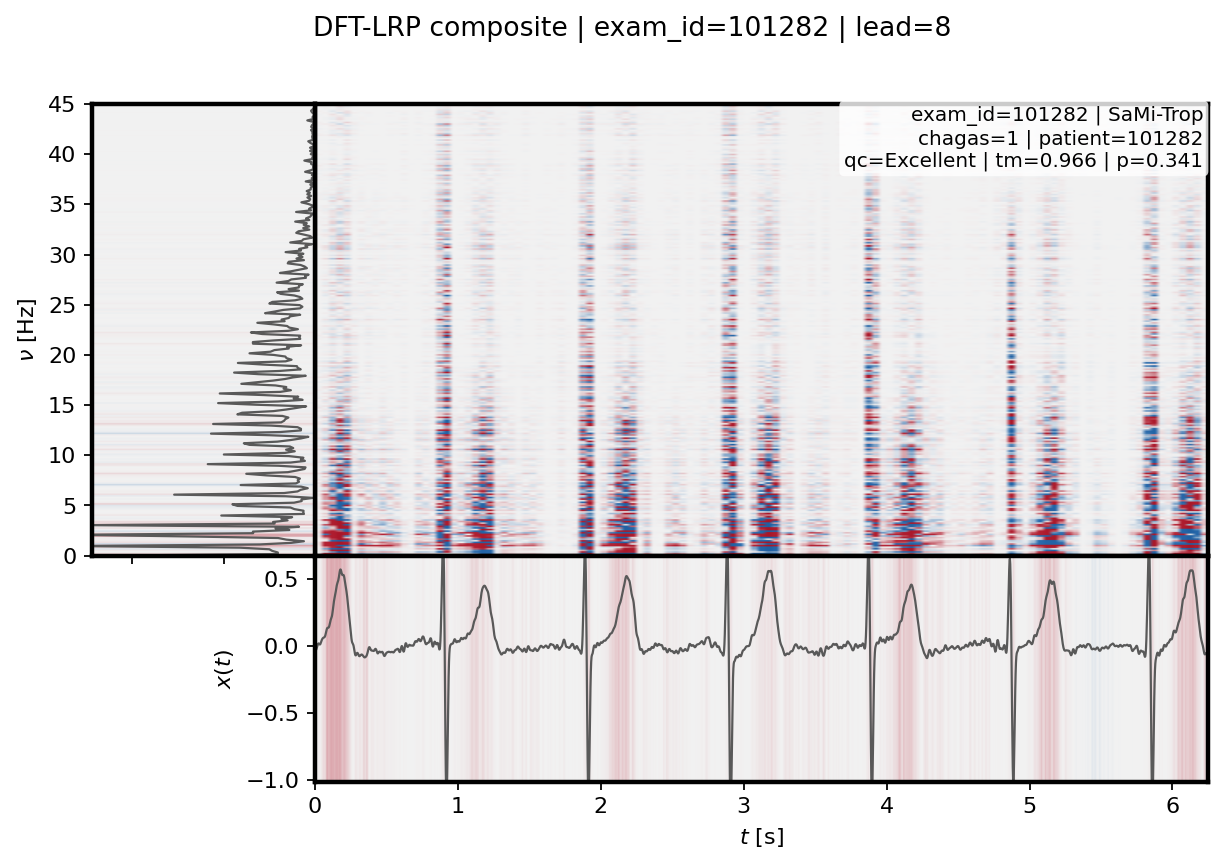

In [9]:
import matplotlib as mpl

# --- knobs ---
CENTER = "signal"  # "signal" (paper-like) or "relevance"
FREQ_MAX_HZ = 45.0     # match the paper look; set to 45.0 for full bandpass
TIME_MAX_S = None      # set e.g. 1.2 to zoom; None uses full window
ALPHA_TIME = 0.35
ALPHA_FREQ = 0.35
EPS = 1e-12
TF_Q = 0.97  # quantile for TF relevance contrast (smaller -> more saturation)
MID_COLOR = "#f2f2f2"  # less harsh than pure white
CMAP_DIV = mpl.colors.LinearSegmentedColormap.from_list("RdBuGrey", ["#2166ac", MID_COLOR, "#b2182b"])

# --- axes in seconds/Hz ---
t = np.arange(T, dtype=np.float32) / FS_HZ
# Use the frequency grid implied by the returned tensors (avoids mismatches).
# With the current upstream implementation, both DFT and STDFT return an RFFT-like layout.
def _rfft_freqs_hz(n_bins: int, fs_hz: float) -> np.ndarray:
    return np.linspace(0.0, float(fs_hz) / 2.0, int(n_bins), dtype=np.float32)

n_freq = int(min(relevance_freq.shape[-1], relevance_timefreq.shape[-1]))
freqs = _rfft_freqs_hz(n_freq, FS_HZ)
k_max = int(np.searchsorted(freqs, float(FREQ_MAX_HZ), side="right"))
k_max = max(1, min(k_max, n_freq))

# Select the sample/lead we already computed
x_t = signal_time[sample_idx].astype(np.float32)
r_t = relevance_time_1d[sample_idx].astype(np.float32)
a_f = np.abs(signal_freq[0, :k_max]).astype(np.float32)
r_f = np.asarray(relevance_freq[0, :k_max]).astype(np.float32)

# Robust normalization for signed relevance overlays
def _robust_norm_signed(x: np.ndarray, q: float = 0.99) -> np.ndarray:
    s = np.quantile(np.abs(x), q) + EPS
    return np.clip(x / s, -1.0, 1.0)

r_tn = _robust_norm_signed(r_t)
r_fn = _robust_norm_signed(r_f)

# Main TF matrices: upstream STDFT returns [1, n_windows, F]
tf_sig = np.abs(np.asarray(signal_timefreq)[0, :, :k_max]).T.astype(np.float32)
tf_rel = np.asarray(relevance_timefreq)[0, :, :k_max].T.astype(np.float32)

# Optional zoom
t_end = float(t[-1])
if TIME_MAX_S is not None:
    t_end = float(min(t_end, TIME_MAX_S))
    tmask = t <= t_end
    x_t = x_t[tmask]
    r_tn = r_tn[tmask]
    t = t[tmask]

# Map TF x-extent using upstream window stepping
n_windows = tf_sig.shape[1]
window_step = int(WINDOW_WIDTH // max(WINDOW_SHIFT, 1))
tf_t_end = ((n_windows - 1) * window_step + WINDOW_WIDTH) / FS_HZ
tf_t_end = min(tf_t_end, t_end)

# Robust scaling for the TF relevance colormap
v = np.quantile(np.abs(tf_rel), TF_Q) + EPS

fig = plt.figure(figsize=(9.0, 5.5), dpi=160)
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[1.2, 4.8],
    height_ratios=[3.2, 1.6],
    wspace=0.0, hspace=0.0,
)

ax_tf = fig.add_subplot(gs[0, 1])
ax_spec = fig.add_subplot(gs[0, 0], sharey=ax_tf)
ax_time = fig.add_subplot(gs[1, 1], sharex=ax_tf)

# ---- center: TF ----
if CENTER == "signal":
    # grayscale signal TF with relevance alpha overlay
    ax_tf.imshow(
        tf_sig,
        aspect="auto", origin="lower",
        extent=[0.0, tf_t_end, 0.0, float(freqs[k_max-1])],
        cmap="gray_r",
    )
    ax_tf.imshow(
        tf_rel,
        aspect="auto", origin="lower",
        extent=[0.0, tf_t_end, 0.0, float(freqs[k_max-1])],
        cmap=CMAP_DIV,
        norm=mpl.colors.TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v),
        alpha=0.95,
    )
else:
    ax_tf.imshow(
        tf_rel,
        aspect="auto", origin="lower",
        extent=[0.0, tf_t_end, 0.0, float(freqs[k_max-1])],
        cmap=CMAP_DIV,
        norm=mpl.colors.TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v),
    )

ax_tf.set_xlim(0.0, t_end)
ax_spec.set_ylabel(r"$\nu$ [Hz]")
ax_tf.set_ylim(0.0, float(FREQ_MAX_HZ))
qc_tm = case_info.get("qc_templatematch_bp", None)
try:
    qc_tm_s = f"{float(qc_tm):.3f}"
except Exception:
    qc_tm_s = "NA"

ax_tf.text(
    0.995, 0.995,
    "\n".join(
        [
            f"exam_id={case_info.get('exam_id', str(TARGET_EXAM_ID))} | {case_info.get('source', '')}",
            f"chagas={case_info.get('chagas', 'NA')} | patient={case_info.get('patient_id', '')}",
            f"qc={case_info.get('qc_zhao2018_bp', '')} | tm={qc_tm_s} | p={prob_sample:.3f}",
        ]
    ),
    transform=ax_tf.transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.80, edgecolor="none", boxstyle="round,pad=0.25"),
)
ax_tf.set_ylabel(r"$u$ [Hz]")
ax_tf.tick_params(labelbottom=False, labelleft=False, left=False)

# ---- bottom: time signal + signed relevance overlay ----
ymin = float(np.quantile(x_t, 0.01))
ymax = float(np.quantile(x_t, 0.99))
pad = 0.05 * (ymax - ymin + EPS)
ymin -= pad
ymax += pad

time_img = np.tile(r_tn[None, :], (2, 1))
ax_time.imshow(
    time_img,
    aspect="auto", origin="lower",
    extent=[float(t[0]), float(t[-1]), ymin, ymax],
    cmap=CMAP_DIV, vmin=-1.0, vmax=1.0,
    alpha=ALPHA_TIME,
)
ax_time.plot(t, x_t, color="0.35", lw=1.0)
ax_time.set_xlim(0.0, t_end)
ax_time.set_ylim(ymin, ymax)
ax_time.set_xlabel(r"$t$ [s]")
ax_time.set_ylabel(r"$x(t)$")

# ---- left: spectrum + signed relevance overlay (horizontal stripes) ----
f = freqs[:k_max].astype(np.float32)
amp_max = float(np.quantile(a_f, 0.99) + EPS)
spec_img = np.tile(r_fn[:, None], (1, 2))
ax_spec.imshow(
    spec_img,
    aspect="auto", origin="lower",
    extent=[0.0, amp_max, 0.0, float(f[-1])],
    cmap=CMAP_DIV, vmin=-1.0, vmax=1.0,
    alpha=ALPHA_FREQ,
)
ax_spec.plot(a_f, f, color="0.35", lw=1.0)
ax_spec.set_ylim(0.0, float(FREQ_MAX_HZ))
ax_spec.set_xlim(0.0, amp_max)
ax_spec.invert_xaxis()
ax_spec.tick_params(labelbottom=False)

# Aesthetics: slightly gray background for less harsh contrast
for a in (ax_spec, ax_tf, ax_time):
    a.set_facecolor(MID_COLOR)

# Make the axes touch like the paper
for a in (ax_spec, ax_tf, ax_time):
    for spine in a.spines.values():
        spine.set_linewidth(2.0)

title_id = exam_id[sample_idx] if isinstance(exam_id, (list, tuple)) else exam_id
fig.suptitle(f"DFT-LRP composite | exam_id={title_id} | lead={LEAD_INDEX+1}", y=0.98)
plt.show()


## 6) Pixel-flipping sanity check (frequency ablation)

This tests whether the frequency relevance is predictive: remove frequency components and measure the drop in predicted probability.


Original p(chagas)=0.3406 | bandstop[5,15]Hz p=0.0629 | Δ=-0.2777


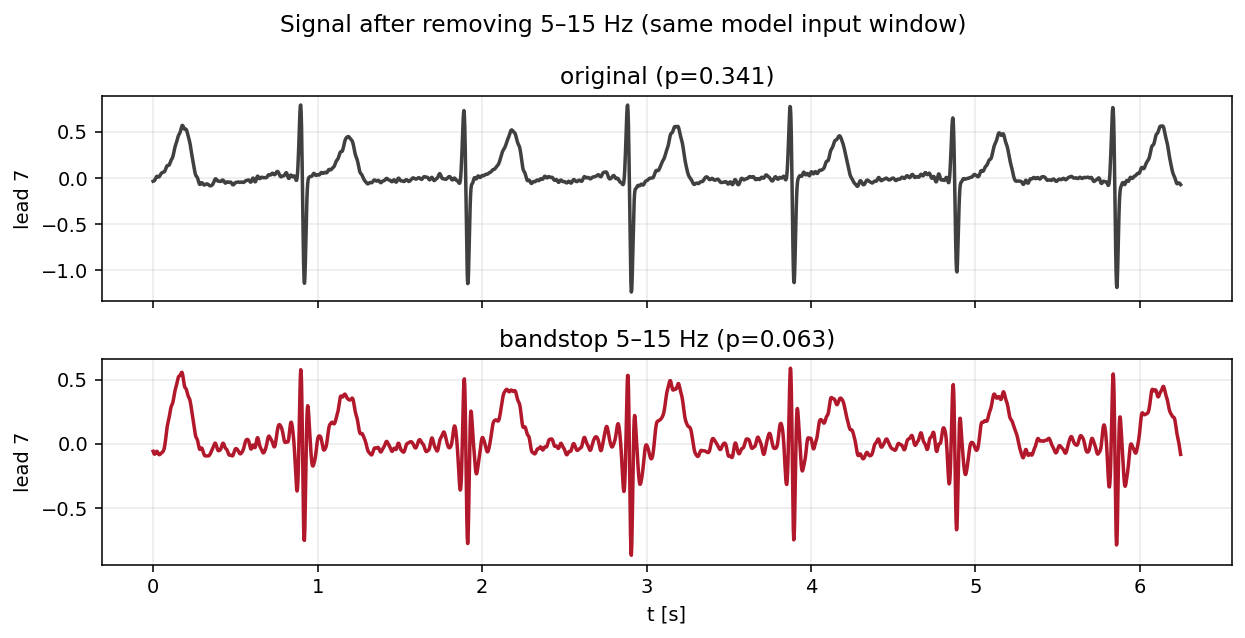

/home/flo178/projects/master-thesis/ecg-chagas-embeddings/external/dft-lrp/code/dft_lrp.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input, dtype=dtype)


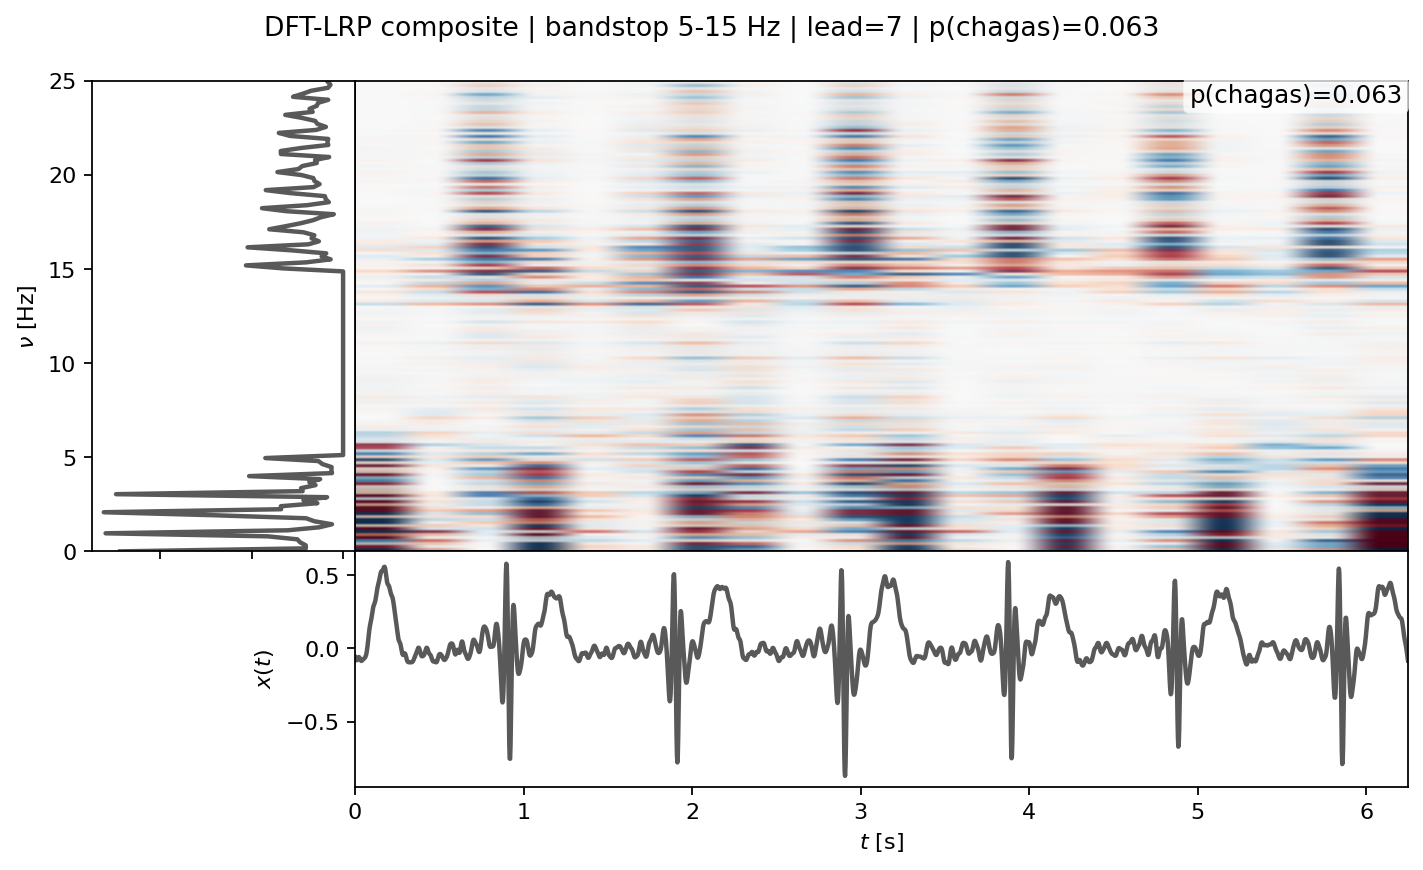

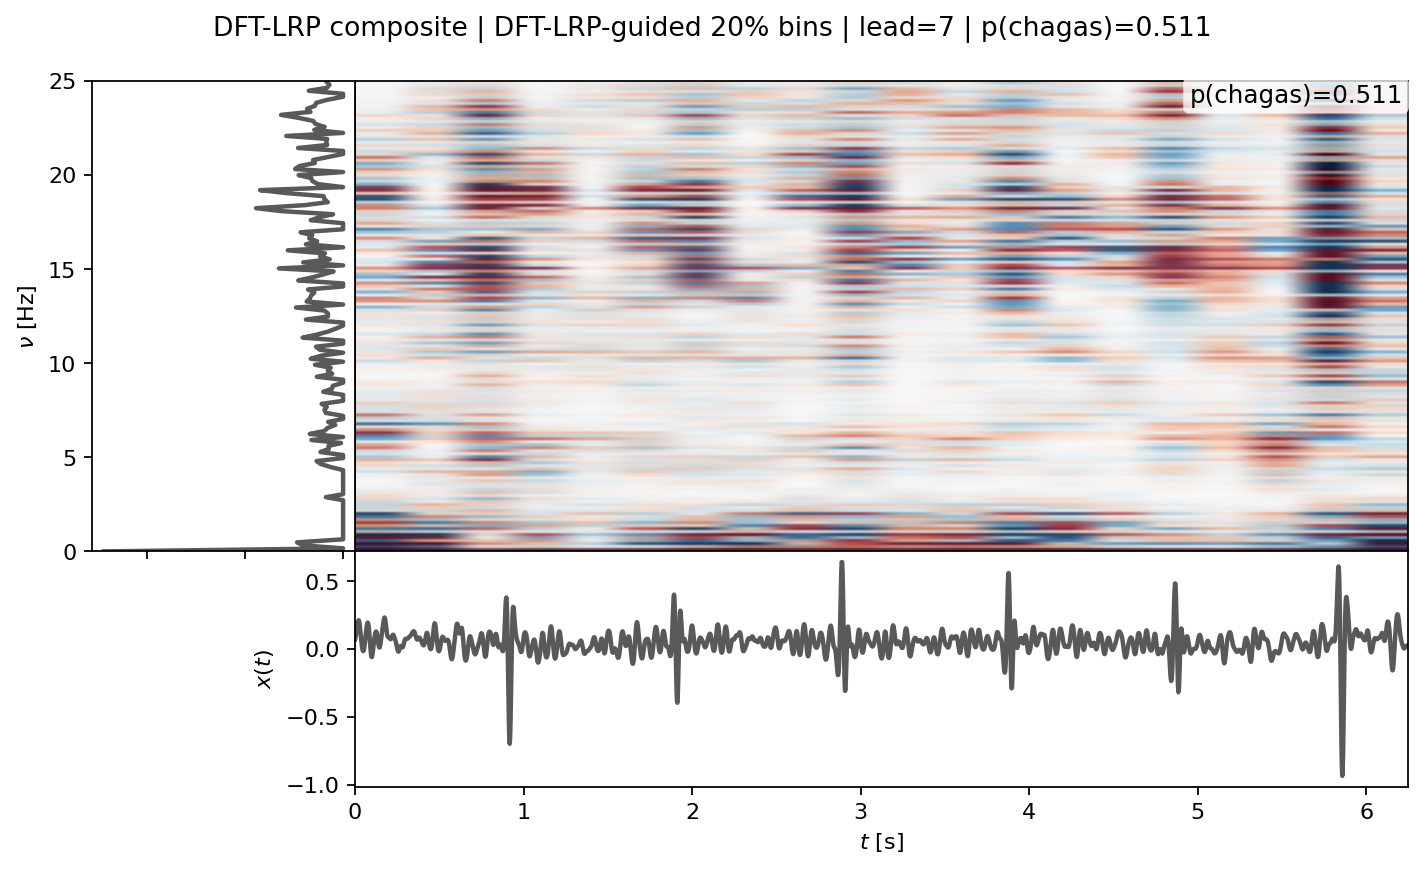

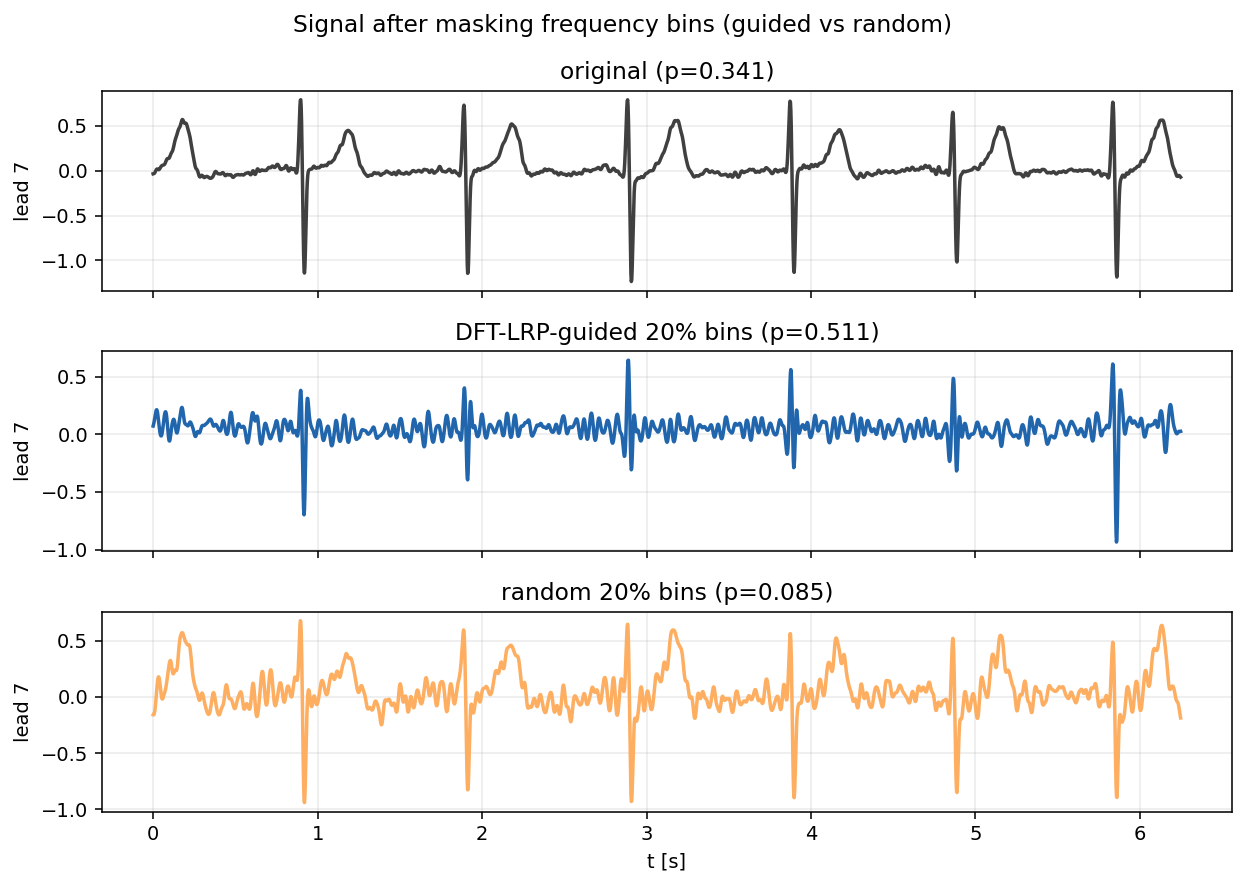

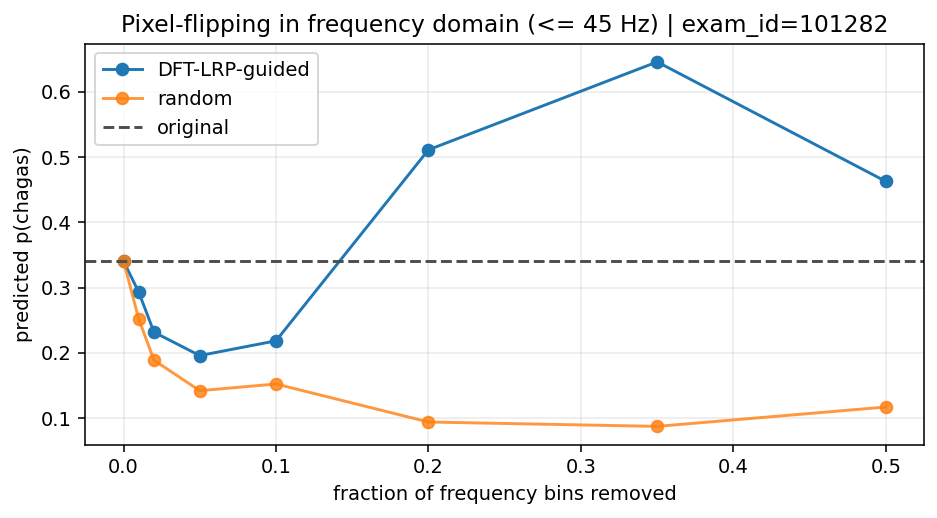

In [10]:
from dataclasses import dataclass

@dataclass
class FlipResult:
    frac_removed: float
    p: float

def _pos_logit(out: torch.Tensor | tuple | list) -> torch.Tensor:
    if isinstance(out, (tuple, list)):
        out = out[-1]
    if out.ndim == 2 and out.shape[1] == 1:
        out = out[:, 0]
    return out

def _predict_prob(x_in: np.ndarray) -> float:
    xt = torch.from_numpy(x_in).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        logit = _pos_logit(model(xt))
        return float(torch.sigmoid(logit)[0].item())

def _bandstop(x_in: np.ndarray, f_lo: float, f_hi: float) -> np.ndarray:
    # x_in: [1,12,T]
    x0 = x_in[0]
    X = np.fft.rfft(x0, axis=-1)
    freqs = np.fft.rfftfreq(x0.shape[-1], d=1.0 / FS_HZ)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    X[:, mask] = 0
    x_bs = np.fft.irfft(X, n=x0.shape[-1], axis=-1).astype(np.float32)
    return x_bs[None, ...]

# --- single-band ablation (e.g. 5–15 Hz) ---
x_one = x[[sample_idx]].detach().cpu().numpy().astype(np.float32)
T_local = int(x_one.shape[-1])
p_orig = _predict_prob(x_one)
x_bs = _bandstop(x_one, 5.0, 15.0)
p_bs = _predict_prob(x_bs)
print(f"Original p(chagas)={p_orig:.4f} | bandstop[5,15]Hz p={p_bs:.4f} | Δ={p_bs - p_orig:+.4f}")

# Optional: also render the Fig.7-like composite for masked signals
SHOW_MASKED_COMPOSITES = True  # set True to recompute DFT-LRP composite for masked inputs
MASKED_FREQ_MAX_HZ = 25.0

def _choose_window_width(signal_length: int, preferred: int = 128, min_w: int = 32, max_w: int = 512) -> int:
    upper = min(max_w, signal_length)
    candidates = [w for w in range(min_w, upper + 1) if signal_length % w == 0]
    if not candidates:
        return signal_length
    return min(candidates, key=lambda w: abs(w - preferred))

def _plot_composite_for_x(x_np: np.ndarray, title_suffix: str) -> None:
    # x_np: [1,12,T]
    xt = torch.from_numpy(x_np).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        logit = _pos_logit(model(xt))
        p = float(torch.sigmoid(logit)[0].item())
    with torch.inference_mode(False), torch.enable_grad(), torch.autocast(device_type=device.type, enabled=False):
        r_time = compute_lrp_relevance_time(pl_module=model, x=xt)
    Tt = x_np.shape[-1]
    lead = int(LEAD_INDEX)
    sig_t = x_np[0, lead]
    rel_t = r_time.detach().cpu().numpy()[0, lead].astype(np.float32)
    # DFT-LRP freq
    dft_obj = dft_lrp.DFTLRP(Tt, leverage_symmetry=True, precision=32, cuda=False, create_stdft=False, create_inverse=False)
    sig_f, rel_f = dft_obj.dft_lrp(rel_t[None, :], sig_t[None, :], real=False, short_time=False, epsilon=1e-6)
    # STDFT
    ww = _choose_window_width(Tt, preferred=128)
    ws = 1
    tf_obj = dft_lrp.DFTLRP(Tt, leverage_symmetry=True, precision=32, cuda=False, window_shift=ws, window_width=ww, window_shape="rectangle", create_dft=False, create_inverse=False)
    sig_tf, rel_tf = tf_obj.dft_lrp(rel_t[None, :], sig_t[None, :], real=False, short_time=True, epsilon=1e-6)
    sig_tf = np.nan_to_num(sig_tf, nan=0.0, posinf=0.0, neginf=0.0)
    rel_tf = np.nan_to_num(rel_tf, nan=0.0, posinf=0.0, neginf=0.0)
    # Reuse the composite style choices from cell 11 (simple variant)
    t = np.arange(Tt, dtype=np.float32) / FS_HZ
    freqs = np.fft.rfftfreq(Tt, d=1.0 / FS_HZ)
    fmask = freqs <= float(MASKED_FREQ_MAX_HZ)
    k_max = int(np.where(fmask)[0][-1]) + 1 if np.any(fmask) else min(200, len(freqs))
    tf_sig = np.abs(np.asarray(sig_tf)[0, :, :k_max]).T
    tf_rel = np.asarray(rel_tf)[0, :, :k_max].T
    v = np.quantile(np.abs(tf_rel), 0.95) + 1e-12
    fig = plt.figure(figsize=(9.0, 5.5), dpi=160)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 4.8], height_ratios=[3.2, 1.6], wspace=0.0, hspace=0.0)
    ax_tf = fig.add_subplot(gs[0, 1])
    ax_spec = fig.add_subplot(gs[0, 0], sharey=ax_tf)
    ax_time = fig.add_subplot(gs[1, 1], sharex=ax_tf)
    ax_tf.imshow(tf_sig, aspect="auto", origin="lower", extent=[0.0, t[-1], 0.0, float(freqs[k_max-1])], cmap="gray_r")
    ax_tf.imshow(tf_rel, aspect="auto", origin="lower", extent=[0.0, t[-1], 0.0, float(freqs[k_max-1])], cmap="RdBu_r", vmin=-v, vmax=v, alpha=0.7)
    ax_tf.set_xlim(0.0, t[-1])
    ax_tf.set_ylim(0.0, float(MASKED_FREQ_MAX_HZ))
    ax_tf.tick_params(labelbottom=False, labelleft=False, left=False)
    ax_tf.text(0.995, 0.995, f"p(chagas)={p:.3f}", transform=ax_tf.transAxes, ha="right", va="top", fontsize=11, bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.25"))
    ax_spec.set_ylabel(r"$\nu$ [Hz]")
    a_f = np.abs(np.asarray(sig_f)[0, :k_max])
    ax_spec.plot(a_f, freqs[:k_max], color="0.35", lw=2.0)
    ax_spec.invert_xaxis()
    ax_spec.set_ylim(0.0, float(MASKED_FREQ_MAX_HZ))
    ax_spec.tick_params(labelbottom=False)
    ax_time.plot(t, sig_t, color="0.35", lw=2.0)
    ax_time.set_xlabel(r"$t$ [s]")
    ax_time.set_ylabel(r"$x(t)$")
    fig.suptitle(f"DFT-LRP composite | {title_suffix} | lead={lead} | p(chagas)={p:.3f}", y=0.98)
    fig.tight_layout()
    plt.show()


# Plot original vs bandstop (time domain, one lead)
lead = int(LEAD_INDEX)
t_full = np.arange(T_local, dtype=np.float32) / FS_HZ
x_orig_1d = x_one[0, lead]
x_bs_1d = x_bs[0, lead]

fig, axs = plt.subplots(2, 1, figsize=(9.0, 4.6), dpi=140, sharex=True)
axs[0].plot(t_full, x_orig_1d, color="0.25", lw=1.8)
axs[0].set_title(f"original (p={p_orig:.3f})")
axs[1].plot(t_full, x_bs_1d, color="#b2182b", lw=1.8)
axs[1].set_title(f"bandstop 5–15 Hz (p={p_bs:.3f})")
for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.set_ylabel(f"lead {lead}")
axs[1].set_xlabel("t [s]")
fig.suptitle("Signal after removing 5–15 Hz (same model input window)")
fig.tight_layout()
plt.show()

# --- DFT-LRP-guided pixel-flipping in frequency domain ---
# Compute per-lead frequency relevance for this sample
with torch.inference_mode(False), torch.enable_grad(), torch.autocast(device_type=device.type, enabled=False):
    r_time = compute_lrp_relevance_time(pl_module=model, x=x[[sample_idx]])  # [1,12,T]

freqs = np.fft.rfftfreq(T_local, d=1.0 / FS_HZ)
FREQ_MAX_FLIP = 45.0
allow = (freqs > 0) & (freqs <= FREQ_MAX_FLIP)

# DFT-LRP frequency relevance (vectorized across leads)
x_np = x_one[0]  # [12,T]
r_np = r_time.detach().cpu().numpy()[0].astype(np.float32)  # [12,T]
dftlrp_local = dft_lrp.DFTLRP(T_local, leverage_symmetry=True, precision=32, cuda=False, create_stdft=False, create_inverse=False)
_, rel_f = dftlrp_local.dft_lrp(r_np, x_np, real=False, short_time=False, epsilon=1e-6)
rel_f = np.asarray(rel_f).astype(np.float32)  # [12,F]
score = np.sum(np.abs(rel_f), axis=0)  # [F]
score = np.where(allow, score, -np.inf)
order = np.argsort(-score)
order = order[np.isfinite(score[order])]

def _mask_bins(x_in: np.ndarray, bins: np.ndarray) -> np.ndarray:
    x0 = x_in[0]
    X = np.fft.rfft(x0, axis=-1)
    X[:, bins] = 0
    x_rec = np.fft.irfft(X, n=x0.shape[-1], axis=-1).astype(np.float32)
    return x_rec[None, ...]

fractions = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
guided: list[FlipResult] = []
random: list[FlipResult] = []
rng = np.random.default_rng(0)
valid_bins = order.copy()

for frac in fractions:
    n = int(round(frac * len(valid_bins)))
    bins_g = valid_bins[:n]
    x_g = _mask_bins(x_one, bins_g)
    guided.append(FlipResult(frac, _predict_prob(x_g)))

    bins_r = rng.choice(valid_bins, size=n, replace=False) if n > 0 else np.array([], dtype=int)
    x_r = _mask_bins(x_one, bins_r)
    random.append(FlipResult(frac, _predict_prob(x_r)))


# Guided vs random example signal at a chosen flip fraction
EXAMPLE_FRAC = 0.20
n_ex = int(round(EXAMPLE_FRAC * len(valid_bins)))
bins_g_ex = valid_bins[:n_ex]
bins_r_ex = rng.choice(valid_bins, size=n_ex, replace=False) if n_ex > 0 else np.array([], dtype=int)
x_g_ex = _mask_bins(x_one, bins_g_ex)
x_r_ex = _mask_bins(x_one, bins_r_ex)
p_g_ex = _predict_prob(x_g_ex)
p_r_ex = _predict_prob(x_r_ex)

if SHOW_MASKED_COMPOSITES:
    _plot_composite_for_x(x_bs, "bandstop 5-15 Hz")
    _plot_composite_for_x(x_g_ex, f"DFT-LRP-guided {EXAMPLE_FRAC:.0%} bins")


fig, axs = plt.subplots(3, 1, figsize=(9.0, 6.4), dpi=140, sharex=True)
axs[0].plot(t_full, x_orig_1d, color="0.25", lw=1.8)
axs[0].set_title(f"original (p={p_orig:.3f})")
axs[1].plot(t_full, x_g_ex[0, lead], color="#2166ac", lw=1.8)
axs[1].set_title(f"DFT-LRP-guided {EXAMPLE_FRAC:.0%} bins (p={p_g_ex:.3f})")
axs[2].plot(t_full, x_r_ex[0, lead], color="#fdae61", lw=1.8)
axs[2].set_title(f"random {EXAMPLE_FRAC:.0%} bins (p={p_r_ex:.3f})")
for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.set_ylabel(f"lead {lead}")
axs[2].set_xlabel("t [s]")
fig.suptitle("Signal after masking frequency bins (guided vs random)")
fig.tight_layout()
plt.show()

plt.figure(figsize=(6.8, 3.8), dpi=140)
plt.plot([r.frac_removed for r in guided], [r.p for r in guided], marker="o", label="DFT-LRP-guided")
plt.plot([r.frac_removed for r in random], [r.p for r in random], marker="o", label="random", alpha=0.8)
plt.axhline(p_orig, color="0.3", lw=1.5, ls="--", label="original")
plt.xlabel("fraction of frequency bins removed")
plt.ylabel("predicted p(chagas)")
plt.title(f"Pixel-flipping in frequency domain (<= {FREQ_MAX_FLIP:g} Hz) | exam_id={exam_id[sample_idx] if isinstance(exam_id, (list, tuple)) else exam_id}")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
